# Tutorial 04: Supervised Pre-training (Representation Learning)

In this tutorial, we bring everything together: the prefix data, the flattened tensors, and the bidirectional GNN compute. Our goal is to see how the GNN learns a "Recursive Truth" by predicting the future of every edge in a search tree.

### The Mechanistic Goal
We want to minimize the **Cross-Entropy Loss** between:
1.  **The Predictor:** The GNN's guess for a move's WDL based on a partial tree.
2.  **The Oracle:** The actual WDL that was found after a much deeper search.

In [1]:
import os
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Setup Path
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
LMCOS_DIR = Path(os.getcwd()).parent
if str(LMCOS_DIR) not in sys.path:
    sys.path.insert(0, str(LMCOS_DIR))

from GNN import ChildWdlModel
from tensorizer import TreeTensorizer
from schema import tree_encoder_feature_schema
from helper_tensorization import build_demo_trees, plot_tree, make_synthetic_pretrain_dataset
from cts_pretrain import consolidate_generated_tree

## Phase 1: Create a Didactic Dataset

To prove the GNN is learning, we'll create 200 trees with a "Hidden Truth":
- `e4` moves always result in a **Win** (100%).
- `d4` moves always result in a **Draw** (100%).
- `h4` moves always result in a **Loss** (100%).

Initially, the model will be clueless. By the end, its predictions should match these targets exactly.

In [2]:
# Generate Train & Test sets
train_batch, train_targets = make_synthetic_pretrain_dataset(n_samples=150)
test_batch, test_targets = make_synthetic_pretrain_dataset(n_samples=50)

print(f"Dataset Created: {train_batch.node_features.shape[0]} training nodes packed into {train_batch.batch_size} trees.")

Dataset Created: 600 training nodes packed into 150 trees.


## Phase 2: The Training Loop

We use the `Adam` optimizer to tilt the GNN's parameters toward the Oracle Truth.

In [3]:
model = ChildWdlModel(k=1, node_feat=5, device='cpu', d_embed=32, d_message=32, n_heads=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
print("Starting Training Loop...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    
    output = model(train_batch)
    loss = F.cross_entropy(output.edge_logits, train_targets)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f}")

print("\nTraining Complete.")

Starting Training Loop...
Epoch 010 | Train Loss: 0.2553
Epoch 020 | Train Loss: 0.0007
Epoch 030 | Train Loss: 0.0000
Epoch 040 | Train Loss: 0.0000
Epoch 050 | Train Loss: 0.0000
Epoch 060 | Train Loss: 0.0000
Epoch 070 | Train Loss: 0.0000
Epoch 080 | Train Loss: 0.0000
Epoch 090 | Train Loss: 0.0000
Epoch 100 | Train Loss: 0.0000

Training Complete.


## Phase 3: Visualize Convergence

A declining loss curve proves that the GNN is successfully optimizing its internal "Address Reading" to match the game outcomes.

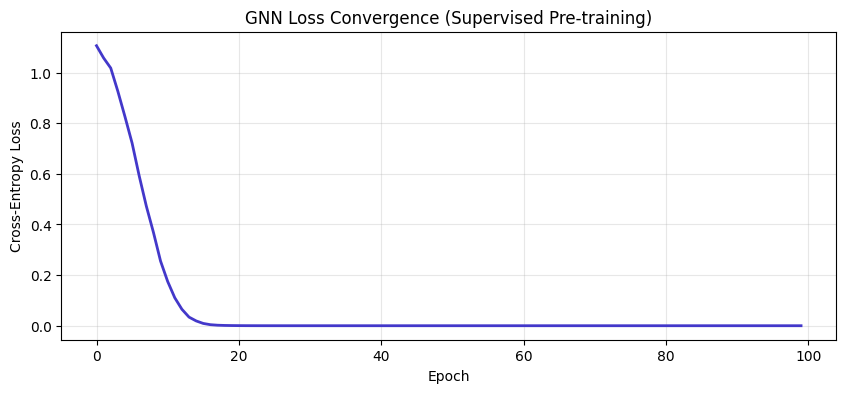

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(losses, color="#4338ca", linewidth=2)
plt.title("GNN Loss Convergence (Supervised Pre-training)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()

## Phase 4: Verification (Did it Learn?)

Now we check the model on the **Test Set** (trees it has never seen). If the loss is low, the GNN has successfully generalized the relationship between Move Slots and Game Outcomes.

In [5]:
model.eval()
with torch.no_grad():
    test_output = model(test_batch)
    test_loss = F.cross_entropy(test_output.edge_logits, test_targets)
    
    # Sample a few predictions
    probs = F.softmax(test_output.edge_logits, dim=-1).numpy()
    
    print(f"Final Test Loss: {test_loss.item():.4f}")
    print("\nSample Predictions (Win | Draw | Loss):")
    for i in range(5):
        target_type = "WIN" if test_targets[i][0] > 0.5 else "DRAW" if test_targets[i][1] > 0.5 else "LOSS"
        print(f"Example {i}: Target={target_type} -> Pred={np.round(probs[i], 2)}")

Final Test Loss: 0.0000

Sample Predictions (Win | Draw | Loss):
Example 0: Target=DRAW -> Pred=[0. 1. 0.]
Example 1: Target=WIN -> Pred=[1. 0. 0.]
Example 2: Target=LOSS -> Pred=[0. 0. 1.]
Example 3: Target=DRAW -> Pred=[0. 1. 0.]
Example 4: Target=WIN -> Pred=[1. 0. 0.]


## Conclusion: The Intuition Engine is Born

By predicting the future of thousands of edges during pre-training, the GNN develops a strong internal "intuition" for chess strategy. 

When we later move to **Reinforcement Learning**, the model won't be starting from zero; it will already have a 32-dimensional understanding of what makes a move look like a "Winner."